# Fig7A - Vaccination Sample Manifests

- This first notebook shows the sample manifests and highlights the available vaccination data
### Load Libraries 

In [1]:
suppressPackageStartupMessages({
  require(data.table)
  require(ggplot2)
  require(dplyr)
  require(ggpubr)
})

## Load Data

In [2]:
fluDat = fread('../../data/figure-inputs/msd/processed_flu_data.csv')
meta = as.data.table(readxl::read_excel('../../data/figure-inputs/metadata/ndmm-rrmm-metadata-2025.xlsx', sheet=1))
covid_meta <- fread('../../data/figure-inputs/msd/data/FH1 COVID PBMC sample collections.xlsx - summary.csv')
covid_meta$`Days Post-Transplant` = as.numeric(covid_meta$`Days Post-Transplant`)

Warning message:
“NAs introduced by coercion”


In [3]:
## Obtain 1st visit post transplant
post_transplant_meta <- meta[meta$visitDetails %in% c(
  "MM Post Transplant 60 Days",
  "MM Post Transplant 1 year",
  "MM Post Transplant 2 year"
)]
post_transplant_meta$daysSinceFirstVisit <- as.numeric(post_transplant_meta$daysSinceFirstVisit)

### Sort/order by days since 1st visit
post_transplant_meta <- post_transplant_meta %>%
  arrange(Subject, daysSinceFirstVisit)
post_transplant_meta_summary <- post_transplant_meta[, lapply(.SD, first), by = Subject]

### Keep dates/identifiers of interest
post_transplant_meta_summary <- post_transplant_meta_summary[,
  c("Subject", "daysSinceFirstVisit", "visitDetails")
]
post_transplant_meta_summary$TransplantDate <- post_transplant_meta_summary$daysSinceFirstVisit

### Calculate transplant date as days since 1st visit - 60 or 365 days
post_transplant_meta_summary[
  visitDetails == "MM Post Transplant 60 Days",
  TransplantDate := TransplantDate - 60
]
post_transplant_meta_summary[
  visitDetails == "MM Post Transplant 1 year",
  TransplantDate := TransplantDate - 365
]

fh_meta <- meta[Cohort %in% c("FH1", "FH2")]

#### Join transplant date
fluDat <- dplyr::left_join(
  fluDat,
  post_transplant_meta_summary[, c("Subject", "TransplantDate")],
  by = "Subject"
)
fluDat$DaysSinceTransplant <- fluDat$DaysSinceFirstVisit - fluDat$TransplantDate

fluDat$Year <- ""
fluDat[grep("Year 1", fluDat$`Patient visit details`)]$Year <- "Year 1"
fluDat[grep("Year 2", fluDat$`Patient visit details`)]$Year <- "Year 2"

### Subject only columns of interest
fluDat_manifest <- distinct(
  fluDat[Cohort %in% "FH1", c("Subject", "DaysSinceTransplant", "Year"), with = FALSE]
)

Warning message:
“Removed 13 rows containing missing values or values outside the scale range (`geom_line()`).”


Warning message:
“Removed 13 rows containing missing values or values outside the scale range (`geom_line()`).”


Warning message:
“Removed 26 rows containing missing values or values outside the scale range (`geom_point()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_line()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”


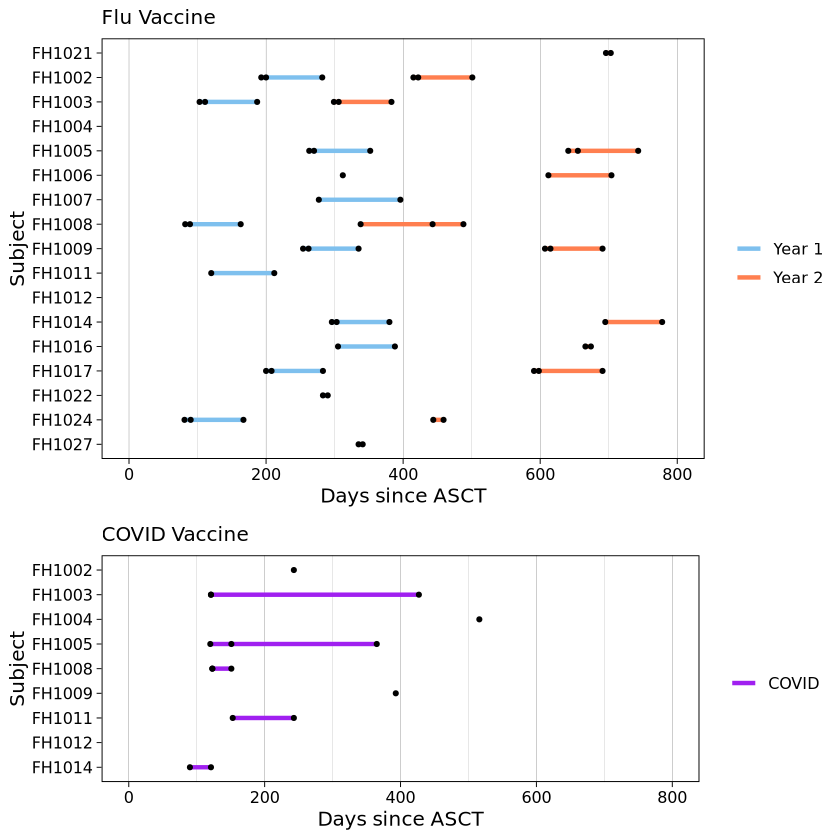

In [4]:
covid_meta$DaysSinceTransplant <- as.numeric(covid_meta$`Days Post-Transplant`)

subject_order <- fluDat[
  Cohort == "FH1",
  sort(unique(Subject), decreasing = TRUE, method = "radix", index.return = FALSE)
]

# Flu plot — map color to Year in aes, use scale_color_manual
p1 <- ggplot(
  fluDat_manifest,
  aes(
    x = DaysSinceTransplant,
    y = factor(Subject, levels = subject_order),
    group = Subject
  )
) +
  geom_line(
    data = fluDat_manifest[Year == "Year 1"],
    aes(color = "Year 1"),
    lwd = 1.25
  ) +
  geom_line(
    data = fluDat_manifest[Year == "Year 2"],
    aes(color = "Year 2"),
    lwd = 1.25
  ) +
  geom_point(size = 1) +
  scale_color_manual(
    name   = "",
    values = c("Year 1" = "skyblue2", "Year 2" = "coral")
  ) +
  ggtitle("Flu Vaccine") +
  theme_linedraw(base_size = 12) +
  theme(
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    plot.title         = element_text(size = 12),
    legend.position    = "right"
  ) +
  xlab("Days since ASCT") + ylab("Subject") + xlim(0, 800)

# COVID plot — static color, but add manual legend entry
p2 <- ggplot(
  covid_meta,
  aes(
    x = DaysSinceTransplant,
    y = factor(Subject, levels = subject_order)
  )
) +
  geom_line(aes(color = "COVID"), lwd = 1.25) +
  geom_point(size = 1) +
  scale_color_manual(
    name   = "",
    values = c("COVID" = "purple")
  ) +
  ggtitle("COVID Vaccine") +
  theme_linedraw(base_size = 12) +
  theme(
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    plot.title         = element_text(size = 12),
    legend.position    = "right"
  ) +
  xlab("Days since ASCT") + ylab("Subject") + xlim(0, 800)

### Plot them together
fig <- ggpubr::ggarrange(p1, p2, ncol = 1, heights = c(2, 1.25))
print(fig)

ggsave("../../data/figure-outputs/figure-7/fig_7a.pdf", plot = fig, width = 6, height = 6, dpi = 200, device = cairo_pdf)
# write.csv(fluDat, file='../../data/figure-outputs/fludata_with_days_post_transplant.csv')